<a href="https://colab.research.google.com/github/Yousra-belg/blackscholes-jumps-deeplearning/blob/main/Copie_de_pinn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PINN — Black-Scholes avec Sauts
**Membre 2** — Architecture du réseau de neurones

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Appareil utilisé :', device)

Appareil utilisé : cuda


In [3]:
#ÉTAPE 1 — Installer et importer les bibliothèques
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Appareil utilisé :", device)

Appareil utilisé : cuda


In [4]:
# Paramètres du modèle (cas n=1 saut, Call européen)
r     = 0.05   # taux sans risque
sigma = 0.20   # volatilité
alpha = 0.10   # amplitude du saut
lam   = 0.50   # intensité risque-neutre λ̃
K     = 100.0  # strike
T     = 1.0    # maturité

In [5]:
#Construire le réseau de neurones: Le réseau prend (t, x) en entrée et retourne V̂(t, x) en sortie.
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),    # entrée : (t, x)
            nn.Tanh(),
            nn.Linear(64, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 1)     # sortie : V(t,x)
        )

    def forward(self, t, x):
        inp = torch.cat([t, x], dim=1)
        return self.net(inp)

model = PINN().to(device)
print(model)

PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [6]:
def sample_points(N_interior, N_terminal):
    t_int = torch.rand(N_interior, 1) * T
    # x entre 20 et 300
    x_int = torch.rand(N_interior, 1) * 280 + 20

    # Points terminaux : t = T, x ∈ [20, 300]
    t_ter = torch.ones(N_terminal, 1) * T
    x_ter = torch.rand(N_terminal, 1) * 280 + 20

    return (t_int.to(device).requires_grad_(True),
            x_int.to(device).requires_grad_(True),
            t_ter.to(device),
            x_ter.to(device))

In [7]:
def loss_fn(model, t_int, x_int, t_ter, x_ter):

    #  PARTIE 1 : résidu EIDP
    V = model(t_int, x_int)
    dV_dt = torch.autograd.grad(V, t_int,
                grad_outputs=torch.ones_like(V),
                create_graph=True)[0]

    dV_dx = torch.autograd.grad(V, x_int,
                grad_outputs=torch.ones_like(V),
                create_graph=True)[0]

    d2V_dx2 = torch.autograd.grad(dV_dx, x_int,
                grad_outputs=torch.ones_like(dV_dx),
                create_graph=True)[0]

    # Terme de saut : V(t, x*(1+alpha))
    x_jump = x_int * (1 + alpha)
    V_jump = model(t_int, x_jump)

    # Résidu de l'EIDP
    residu = (-r * V
              + dV_dt
              + r * x_int * dV_dx
              + 0.5 * sigma**2 * x_int**2 * d2V_dx2
              + lam * (V_jump - V - x_int * alpha * dV_dx))

    loss_eidp = torch.mean(residu**2)

    # ── PARTIE 2 : condition terminale φ(x) = (x-K)⁺
    V_ter = model(t_ter, x_ter)
    payoff = torch.clamp(x_ter - K, min=0)
    loss_terminal = torch.mean((V_ter - payoff)**2)

    return loss_eidp + loss_terminal, loss_eidp, loss_terminal

In [9]:
#Entraîner le modèle
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

losses = []

for epoch in range(10000):
    t_int, x_int, t_ter, x_ter = sample_points(2000, 500)

    optimizer.zero_grad()
    loss, l_eidp, l_ter = loss_fn(model, t_int, x_int, t_ter, x_ter)
    loss.backward()
    optimizer.step()
    scheduler.step()

    losses.append(loss.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d} | Loss totale: {loss.item():.6f} "
              f"| EIDP: {l_eidp.item():.6f} | Terminal: {l_ter.item():.6f}")

Epoch     0 | Loss totale: 55.278774 | EIDP: 0.487872 | Terminal: 54.790901
Epoch   500 | Loss totale: 14.571326 | EIDP: 1.152330 | Terminal: 13.418997
Epoch  1000 | Loss totale: 6.518912 | EIDP: 0.572541 | Terminal: 5.946371
Epoch  1500 | Loss totale: 4.998620 | EIDP: 3.026525 | Terminal: 1.972094
Epoch  2000 | Loss totale: 22.582350 | EIDP: 0.758792 | Terminal: 21.823559
Epoch  2500 | Loss totale: 0.552034 | EIDP: 0.174681 | Terminal: 0.377354
Epoch  3000 | Loss totale: 0.413686 | EIDP: 0.059905 | Terminal: 0.353781
Epoch  3500 | Loss totale: 0.758914 | EIDP: 0.117408 | Terminal: 0.641506
Epoch  4000 | Loss totale: 0.561188 | EIDP: 0.065086 | Terminal: 0.496102
Epoch  4500 | Loss totale: 0.179579 | EIDP: 0.035223 | Terminal: 0.144356
Epoch  5000 | Loss totale: 0.151036 | EIDP: 0.035765 | Terminal: 0.115271
Epoch  5500 | Loss totale: 0.211224 | EIDP: 0.050849 | Terminal: 0.160376
Epoch  6000 | Loss totale: 2.765152 | EIDP: 0.488307 | Terminal: 2.276845
Epoch  6500 | Loss totale: 0.101

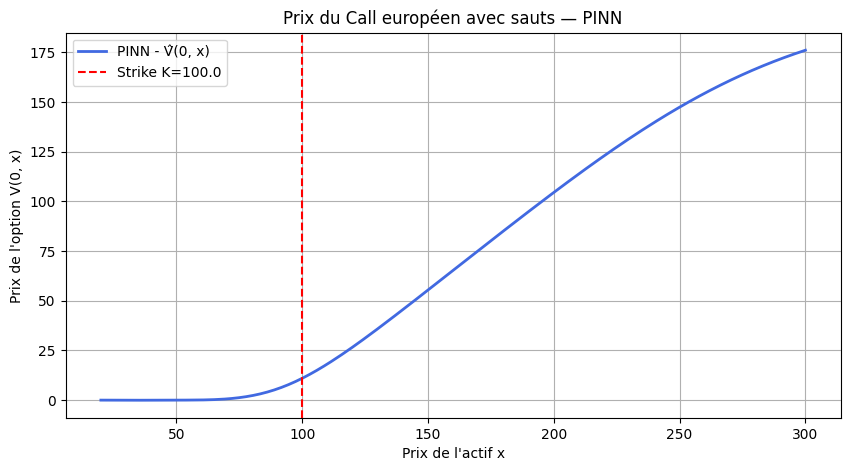

In [10]:
# Grille de visualisation
x_vals = np.linspace(20, 300, 200)
t_val  = 0.0

t_plot = torch.tensor([[t_val]] * 200, dtype=torch.float32).to(device)
x_plot = torch.tensor(x_vals.reshape(-1, 1), dtype=torch.float32).to(device)

with torch.no_grad():
    V_pred = model(t_plot, x_plot).cpu().numpy()

plt.figure(figsize=(10, 5))
plt.plot(x_vals, V_pred, label="PINN - V̂(0, x)", color="royalblue", linewidth=2)
plt.axvline(x=K, color="red", linestyle="--", label=f"Strike K={K}")
plt.xlabel("Prix de l'actif x")
plt.ylabel("Prix de l'option V(0, x)")
plt.title("Prix du Call européen avec sauts — PINN")
plt.legend()
plt.grid(True)
plt.show()